#Implementación de una Red Neuronal para Clasificación Multiclase en TensorFlow Keras o PyTorch (sin Convolución)

#**Importación de Librerías**

In [13]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

#**Carga de Datos**

In [14]:
(X_train, y_train),(X_test, y_test)=keras.datasets.mnist.load_data()

#Variables que asignan el valor al Learning Rate
LRATE=0.0001 #Variebla para Learmning Rate bajo
HRATE=0.01 #Variable para learning Rate Alto

#Normalizar

X_train=X_train / 255.0
X_test=X_test / 255.0

#Aplanar

X_train= X_train.reshape(-1, 28*28)
X_test= X_test.reshape(-1, 28*28)

#**Creación del Modelo**

In [15]:
def crear_modelo(learning_rate):
    model=keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    optimizer=keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#**Experimento**

#**Configuración A**
Learning rate bajo

In [16]:
print ("----------- Configuración A con Learning Rate Bajo -------------")
print("Valor asignado al Learning Rate ", LRATE)
model_A=crear_modelo(LRATE)

history_A=model_A.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

----------- Configuración A con Learning Rate Bajo -------------
Valor asignado al Learning Rate  0.0001
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8547 - loss: 0.5564 - val_accuracy: 0.9243 - val_loss: 0.2759
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9313 - loss: 0.2454 - val_accuracy: 0.9390 - val_loss: 0.2086
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9450 - loss: 0.1931 - val_accuracy: 0.9523 - val_loss: 0.1702
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9538 - loss: 0.1610 - val_accuracy: 0.9573 - val_loss: 0.1517
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9606 - loss: 0.1377 - val_accuracy: 0.9613 - val_loss: 0.1309
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9658 - loss: 0.1201 - val_accuracy: 0.9657 - val_loss: 0.1207
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9699 - loss: 0.1059 - val_accuracy: 0.9661 - va

#**Configuración B**
Learning rate alto

In [17]:
print ("----------- Configuración B con Learning Rate Alto -------------")
print("Valor asignado al Learning Rate ", HRATE)
model_B=crear_modelo(HRATE)

history_B=model_B.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

----------- Configuración B con Learning Rate Alto -------------
Valor asignado al Learning Rate  0.01
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9246 - loss: 0.2592 - val_accuracy: 0.9470 - val_loss: 0.1937
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9513 - loss: 0.1811 - val_accuracy: 0.9491 - val_loss: 0.2058
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9585 - loss: 0.1545 - val_accuracy: 0.9621 - val_loss: 0.1523
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9614 - loss: 0.1469 - val_accuracy: 0.9567 - val_loss: 0.1895
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9648 - loss: 0.1344 - val_accuracy: 0.9631 - val_loss: 0.1561
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9676 - loss: 0.1275 - val_accuracy: 0.9627 - val_loss: 0.1631
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9702 - loss: 0.1190 - val_accuracy: 0.9586 - val

#**Graficación de Resultados**

#Loss

--------- Graficando Loss ---------


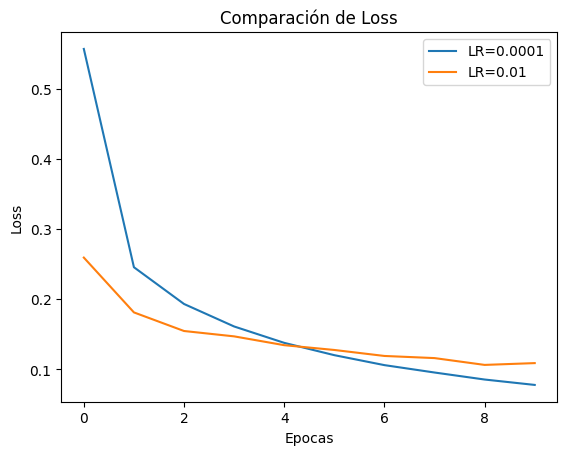

In [18]:
print("--------- Graficando Loss ---------")

plt.plot(history_A.history['loss'], label='LR='+str(LRATE))
plt.plot(history_B.history['loss'], label='LR='+str(HRATE))

plt.title("Comparación de Loss")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Accuracy

--------- Graficando Accuracy -------


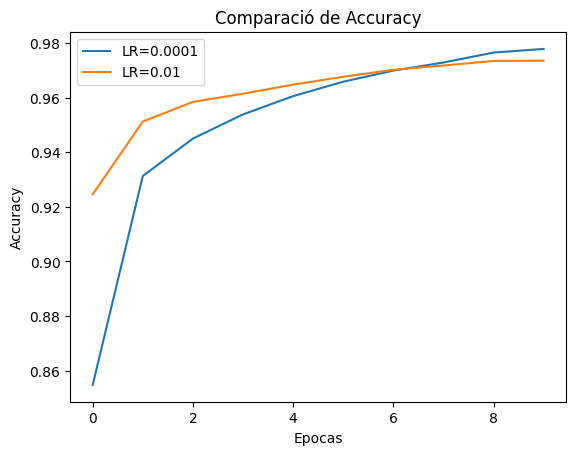

In [19]:
print("--------- Graficando Accuracy -------")

plt.plot(history_A.history['accuracy'], label='LR='+str(LRATE))
plt.plot(history_B.history['accuracy'], label='LR='+str(HRATE))

plt.title("Comparació de Accuracy")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()